<a href="https://colab.research.google.com/github/Gratitude01-ndam/Exam1/blob/main/Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MAPE: 2.02%


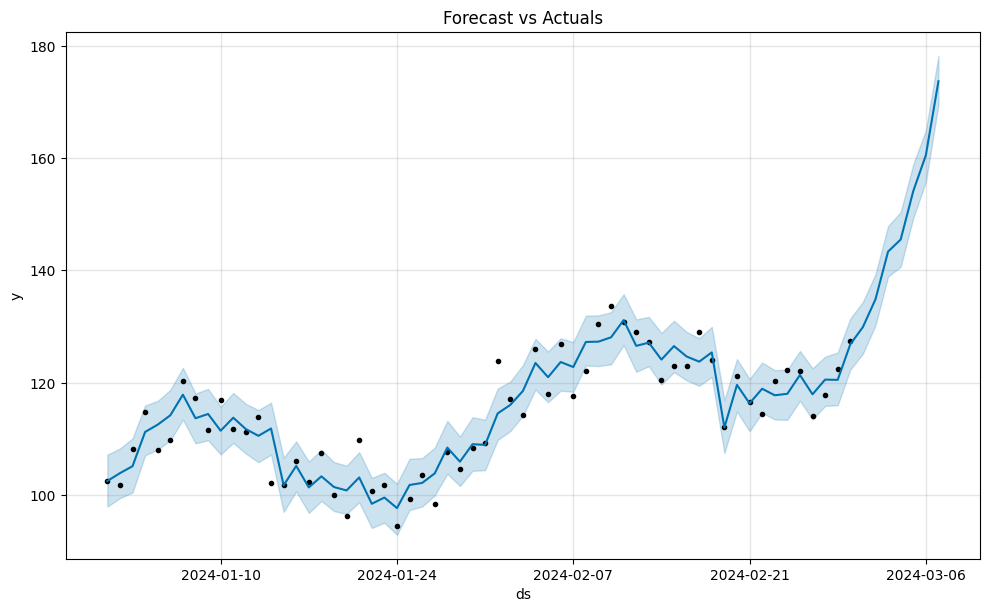

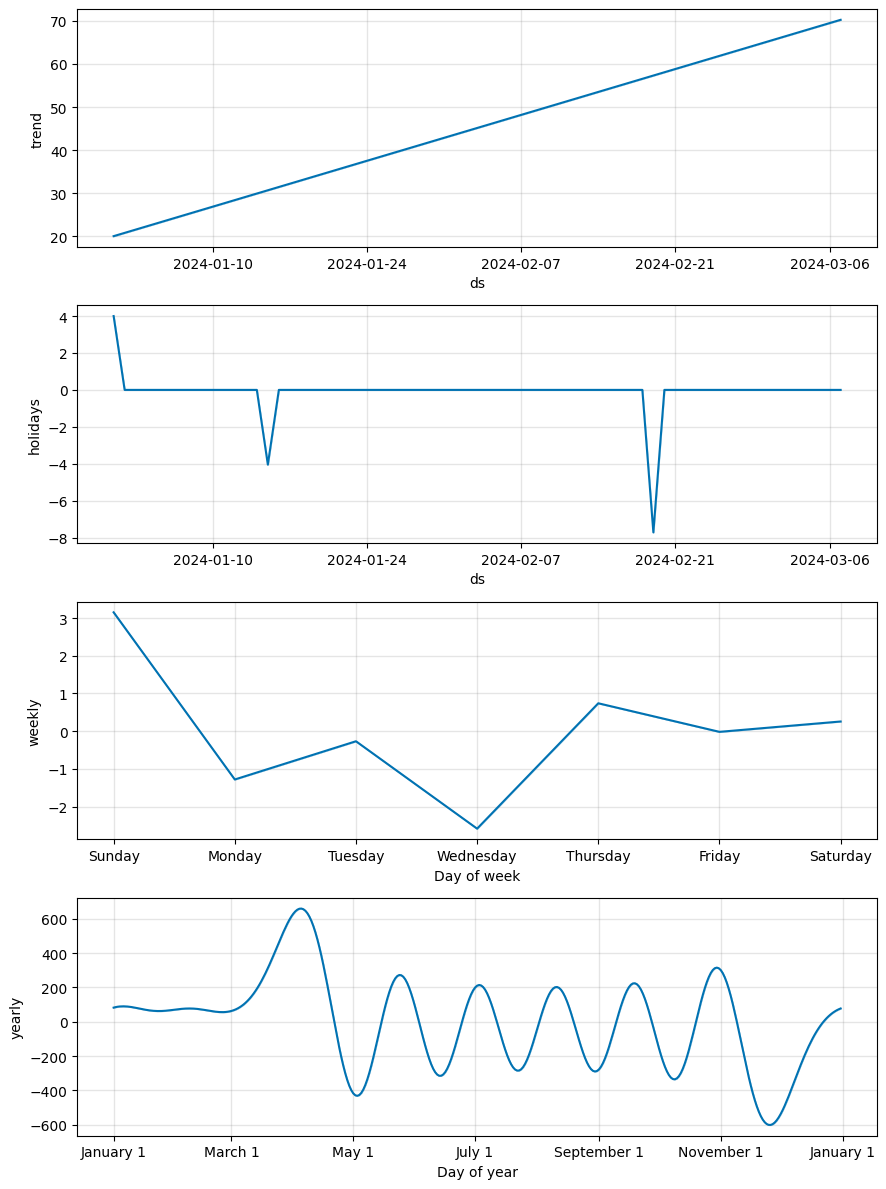

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error

# 1. Create synthetic dataset (60 days of trips with trend + seasonality + noise)
np.random.seed(42)
dates = pd.date_range(start='2024-01-01', periods=60, freq='D')
trips = 100 + 10*np.sin(np.arange(60)/5) + np.arange(60)*0.5 + np.random.normal(0,5,60)

df = pd.DataFrame({'Date': dates, 'Trips': trips})

# 2. Prepare Data for Prophet
ts_df = df[['Date', 'Trips']].rename(columns={'Date': 'ds', 'Trips': 'y'})

# 3. Build & Fit Model
model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model.add_country_holidays(country_name='US')
model.fit(ts_df)

# 4. Forecast Next 7 Days
future = model.make_future_dataframe(periods=7)
forecast = model.predict(future)

# 5. Evaluate Accuracy (MAPE on last 7 days)
y_true = ts_df['y'].tail(7)
y_pred = forecast['yhat'].iloc[-14:-7]  # Align forecast window
mape = mean_absolute_percentage_error(y_true, y_pred)
print(f"MAPE: {mape:.2%}")

# 6. Plot Forecast
fig1 = model.plot(forecast)
plt.title("Forecast vs Actuals")
plt.show()

# 7. Plot Components (trend, seasonality, holidays)
fig2 = model.plot_components(forecast)
plt.show()